In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Анализ видео-контента и популярности в вордстате

In [36]:
wordstat = pd.read_csv('wordstat (2).csv')
videos = pd.read_csv('career_videos.csv')


videos.head()


,company_name,title,channel_title,video_type,description,video_category,published_at,duration,subscriber_count,view_count,like_count,days_from_publication,interest_score,tags,video_url
0,Yandex,Ты все еще хочешь работать в Яндекс?,Антон Назаров I Осознанная Меркантильность,shorts,Узнаем подробности работы в Яндексе от жоского...,Education,2025-05-19T06:14:07Z,PT59S,52100,258468,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k
1,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",Яндекс,shorts,NaN,Science & Technology,2023-08-05T08:35:52Z,PT55S,474000,94269,1395,978,2.674206e+04,[],https://youtu.be/CuQ0iqA0vsI
2,Yandex,Кого я НИКОГДА не возьму в Яндекс? #работа #пс...,Irina Panfilova,shorts,"🚀 Хотите построить карьеру в IT, но не знаете,...",People & Blogs,2025-07-01T21:00:54Z,PT25S,1350,4573,10,281,5.512674e+02,"['карьера it', 'карьера', 'it', 'it компания',...",https://youtu.be/ljHUMWtCqEY
3,Yandex,Школа разработки от Яндекс #IT #работа,Не сидится,shorts,@necdtsa - полный выпуск на канале!,Science & Technology,2023-05-29T16:49:15Z,PT10S,1260,1130,9,1045,8.727956e+00,[],https://youtu.be/DHlhJdY_VPM
4,Yandex,🤑 Сколько стажёрам платят в Яндексе?,Яндекс,shorts,NaN,Science & Technology,2023-09-29T11:31:38Z,PT36S,474000,52961,551,922,3.536346e+03,[],https://youtu.be/5o8U5FPnj54


In [37]:
wordstat.head()

,company,rating,market,revenue,growth,market_num,search_name,вакансии,вакансии_top,стажировка,стажировка_top,собеседования,собеседования_top,total,зарплата_общая,зарплата_top_общий
0,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10,яндекс,181510,"[{'phrase': 'яндекс вакансии', 'count': '82123...",17302,"[{'phrase': 'яндекс стажировка', 'count': '124...",4423,"[{'phrase': 'собеседование в яндекс', 'count':...",232175,28940.0,"[{'phrase': 'зп в яндексе', 'count': '1465'}, ..."
1,Т-Банк,2,"Экосистема, Fintech, TravelTech, Telecom, Edte...","962,00","+162,8%",6,тбанк,10467,"[{'phrase': 'тбанк вакансии', 'count': '7724'}...",3506,"[{'phrase': 'тбанк стажировка', 'count': '3051...",273,"[{'phrase': 'собеседование тбанк', 'count': '2...",15764,1518.0,"[{'phrase': 'тбанк зп', 'count': '347'}, {'phr..."
2,Wildberries,3,"Экосистема, E-com, TravelTech, Fintech","657,50 *","+107,3%",4,вб,32408,"[{'phrase': 'вб вакансии', 'count': '14879'}, ...",2956,"[{'phrase': 'вб стажировка', 'count': '1318'},...",130,"[{'phrase': 'собеседование на вб', 'count': '1...",59026,23532.0,"[{'phrase': 'зп на вб', 'count': '2174'}, {'ph..."
3,Ozon,4,"Экосистема, E-com, Traveltech, Fintech","615,70","+122,2%",4,озон,208544,"[{'phrase': 'озон вакансии', 'count': '89707'}...",5500,"[{'phrase': 'озон стажировка', 'count': '3835'...",1029,"[{'phrase': 'озон собеседование', 'count': '60...",274901,59828.0,"[{'phrase': 'зп на озоне', 'count': '2795'}, {..."
4,Ростелеком (цифровые активы),5,"Экосистема, Telecom, Gametech, Edtech","341,40 *","+30,9%",4,ростелеком,15048,"[{'phrase': 'ростелеком вакансии', 'count': '8...",577,"[{'phrase': 'ростелеком стажировка', 'count': ...",265,"[{'phrase': 'ростелеком собеседование', 'count...",17058,1168.0,"[{'phrase': 'зп в ростелекоме', 'count': '101'..."


In [38]:
videos.shape

(2725, 15)

In [39]:
wordstat.shape

(100, 16)

In [40]:
videos.columns

Index(['company_name', 'title', 'channel_title', 'video_type', 'description',
       'video_category', 'published_at', 'duration', 'subscriber_count',
       'view_count', 'like_count', 'days_from_publication', 'interest_score',
       'tags', 'video_url'],
      dtype='object')

In [47]:
dict_rus_eng = {
    'Astrum Entertainment': 'аструм',
    'ИТ-холдинг Т1': 'т1',
    '1520 Сигнал (входит в экосистему РЖД)': 'ржд',
    'Лаборатория Касперского': 'касперский',
    'Ростелеком (цифровые активы)': 'ростелеком',
    'Сбер (цифровые активы)': 'сбер',
    'МТС (цифровые активы)': 'мтс',
    'Т-Банк': 'тбанк',
    'Yandex': 'яндекс',
    'Wildberries': 'вб',
    'Ozon': 'озон',
    'Edna': 'эдна',
    'Softline': 'софтлайн',
    'VK': 'вк',
    'Lamoda': 'ламода',
    'HH': 'хх',
    'Saby (Тензор)': 'тензор',
    'CloudPayments + CloudTips + CloudKassir': 'cloud',
    'Naumen': 'наумен',
    'VisorLabs': 'визорлабс',
    'Arenadata': 'аренадата',
    'Холдинг Performance Group': 'performance group',
    'BelkaCar': 'белка кар',
    'Getcourse': 'геткурс',
    'Grow Food': 'гроу фуд',
    'Litres (принадлежит Эксмо-АСТ)': 'литрес',
    '«ланит»:': 'ланит'
}

In [48]:
import re

def normalize_name(name):
  name = name.strip()
  name = re.sub(r'^гк\s+', '', name, flags=re.IGNORECASE)  # убрать ГК в начале - это влияет на запросы в вордстате
  name = re.sub(r'\s*\(цифровые активы\)\s*$', '', name, flags=re.IGNORECASE) #убираем в конце цифровые активы чтобы не портить статистику запросов
  return name.strip()

def get_value(name):
  cleaned_name = normalize_name(name)

  for k, v in dict_rus_eng.items():
    if normalize_name(k).lower() == cleaned_name.lower():
      return v
  return cleaned_name.lower()

videos['search_name'] = videos['company_name'].apply(get_value)
videos['search_name']


,search_name
0,яндекс
1,яндекс
2,яндекс
3,яндекс
4,яндекс
...,...
2720,tutu.ru
2721,tutu.ru
2722,tutu.ru
2723,tutu.ru


In [49]:
vw = pd.merge(videos, wordstat, on='search_name', how='left', suffixes=('', '_ws'))

vw.head()

,company_name,title,channel_title,video_type,description,video_category,published_at,duration,subscriber_count,view_count,...,market_num,вакансии,вакансии_top,стажировка,стажировка_top,собеседования,собеседования_top,total,зарплата_общая,зарплата_top_общий
0,Yandex,Ты все еще хочешь работать в Яндекс?,Антон Назаров I Осознанная Меркантильность,shorts,Узнаем подробности работы в Яндексе от жоского...,Education,2025-05-19T06:14:07Z,PT59S,52100,258468,...,10,181510,"[{'phrase': 'яндекс вакансии', 'count': '82123...",17302,"[{'phrase': 'яндекс стажировка', 'count': '124...",4423,"[{'phrase': 'собеседование в яндекс', 'count':...",232175,28940.0,"[{'phrase': 'зп в яндексе', 'count': '1465'}, ..."
1,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",Яндекс,shorts,NaN,Science & Technology,2023-08-05T08:35:52Z,PT55S,474000,94269,...,10,181510,"[{'phrase': 'яндекс вакансии', 'count': '82123...",17302,"[{'phrase': 'яндекс стажировка', 'count': '124...",4423,"[{'phrase': 'собеседование в яндекс', 'count':...",232175,28940.0,"[{'phrase': 'зп в яндексе', 'count': '1465'}, ..."
2,Yandex,Кого я НИКОГДА не возьму в Яндекс? #работа #пс...,Irina Panfilova,shorts,"🚀 Хотите построить карьеру в IT, но не знаете,...",People & Blogs,2025-07-01T21:00:54Z,PT25S,1350,4573,...,10,181510,"[{'phrase': 'яндекс вакансии', 'count': '82123...",17302,"[{'phrase': 'яндекс стажировка', 'count': '124...",4423,"[{'phrase': 'собеседование в яндекс', 'count':...",232175,28940.0,"[{'phrase': 'зп в яндексе', 'count': '1465'}, ..."
3,Yandex,Школа разработки от Яндекс #IT #работа,Не сидится,shorts,@necdtsa - полный выпуск на канале!,Science & Technology,2023-05-29T16:49:15Z,PT10S,1260,1130,...,10,181510,"[{'phrase': 'яндекс вакансии', 'count': '82123...",17302,"[{'phrase': 'яндекс стажировка', 'count': '124...",4423,"[{'phrase': 'собеседование в яндекс', 'count':...",232175,28940.0,"[{'phrase': 'зп в яндексе', 'count': '1465'}, ..."
4,Yandex,🤑 Сколько стажёрам платят в Яндексе?,Яндекс,shorts,NaN,Science & Technology,2023-09-29T11:31:38Z,PT36S,474000,52961,...,10,181510,"[{'phrase': 'яндекс вакансии', 'count': '82123...",17302,"[{'phrase': 'яндекс стажировка', 'count': '124...",4423,"[{'phrase': 'собеседование в яндекс', 'count':...",232175,28940.0,"[{'phrase': 'зп в яндексе', 'count': '1465'}, ..."


In [50]:
vw[vw.вакансии_top.isna() == True]

,company_name,title,channel_title,video_type,description,video_category,published_at,duration,subscriber_count,view_count,...,market_num,вакансии,вакансии_top,стажировка,стажировка_top,собеседования,собеседования_top,total,зарплата_общая,зарплата_top_общий


In [69]:
vw.duplicated().sum()

np.int64(0)

In [70]:
vw = vw.drop_duplicates().copy()

In [52]:
vw.dtypes

,0
company_name,object
title,object
channel_title,object
video_type,object
description,object
video_category,object
published_at,object
duration,object
subscriber_count,int64
view_count,int64


In [59]:
vw.nunique()

,0
company_name,35
title,1167
channel_title,769
video_type,2
description,1006
video_category,11
published_at,1171
duration,784
subscriber_count,630
view_count,1049


Переведем в числовой тип следующие признаки:
- duration - в секунды
- revenue
- growth
- video_type (0 - video, 1 - shorts)
- video_category (OHE - 11 категорий)

Также создадим прокси метрики качества в качестве дополнения основной метрики интересности, посчитанной ранее:
- Уровень вовлеченности
- просмотры/подписчики
- лайки/подписчики


published_at - в тип datetime

https://pypi.org/project/isodate/ - библиотека для обработки duration

In [63]:
!pip install isodate

In [66]:
import isodate

# published_at
vw['published_at'] = pd.to_datetime(vw['published_at'], errors='coerce')

#duration
def dur_sec(x):
    if pd.isna(x):
        return np.nan
    return isodate.parse_duration(str(x)).total_seconds()


vw['duration_sec'] = vw['duration'].apply(dur_sec)

# revenue
vw['revenue_num'] = (
    vw['revenue']
    .astype(str)
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9.\-]', '', regex=True)
    .replace('', np.nan)
)

#growth
vw['growth_num'] = (
    vw['growth']
    .astype(str)
    .str.replace('\xa0', ' ', regex=False)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9.\-]', '', regex=True)
    .replace('', np.nan)
)

vw['growth_num'] = pd.to_numeric(vw['growth_num'], errors='coerce')

vw['revenue_num'] = pd.to_numeric(vw['revenue_num'], errors='coerce')

#video_type
video_types = {'video': 0, 'shorts': 1}

# shorts
vw['shorts'] = vw['video_type'].map(video_types)

# category
video_category_ohe = pd.get_dummies(
    vw['video_category'],
    prefix='video_category',
    dtype=int
)

vw = pd.concat([vw, video_category_ohe], axis=1)



Прокси метрики:

In [68]:
vw['engage'] = vw['like_count'] / vw['view_count'].replace(0, np.nan)
vw['views_subs'] = vw['view_count'] / vw['subscriber_count'].replace(0, np.nan)
vw['likes_subs'] = vw['like_count'] / vw['subscriber_count'].replace(0, np.nan)

In [72]:
vw.head()

,company_name,title,channel_title,video_type,description,video_category,published_at,duration,subscriber_count,view_count,...,video_category_Film & Animation,video_category_Gaming,video_category_Howto & Style,video_category_News & Politics,video_category_People & Blogs,video_category_Science & Technology,video_category_Travel & Events,engage,views_subs,likes_subs
0,Yandex,Ты все еще хочешь работать в Яндекс?,Антон Назаров I Осознанная Меркантильность,shorts,Узнаем подробности работы в Яндексе от жоского...,Education,2025-05-19 06:14:07+00:00,PT59S,52100,258468,...,0,0,0,0,0,0,0,0.009769,4.960998,0.048464
1,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",Яндекс,shorts,NaN,Science & Technology,2023-08-05 08:35:52+00:00,PT55S,474000,94269,...,0,0,0,0,0,1,0,0.014798,0.198880,0.002943
2,Yandex,Кого я НИКОГДА не возьму в Яндекс? #работа #пс...,Irina Panfilova,shorts,"🚀 Хотите построить карьеру в IT, но не знаете,...",People & Blogs,2025-07-01 21:00:54+00:00,PT25S,1350,4573,...,0,0,0,0,1,0,0,0.002187,3.387407,0.007407
3,Yandex,Школа разработки от Яндекс #IT #работа,Не сидится,shorts,@necdtsa - полный выпуск на канале!,Science & Technology,2023-05-29 16:49:15+00:00,PT10S,1260,1130,...,0,0,0,0,0,1,0,0.007965,0.896825,0.007143
4,Yandex,🤑 Сколько стажёрам платят в Яндексе?,Яндекс,shorts,NaN,Science & Technology,2023-09-29 11:31:38+00:00,PT36S,474000,52961,...,0,0,0,0,0,1,0,0.010404,0.111732,0.001162


<Axes: >

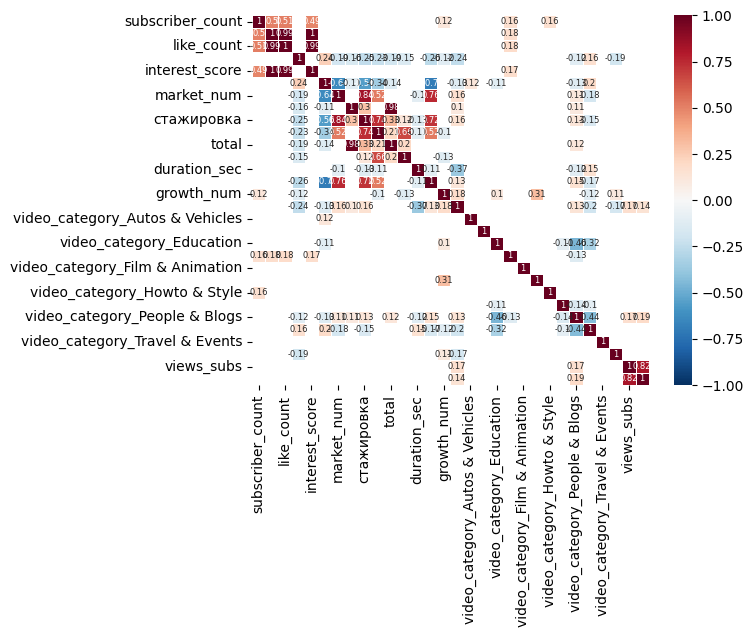

In [71]:
import seaborn as sns

corr = vw.corr(numeric_only=True)
mask = corr.abs() <= 0.1
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap='RdBu_r', annot=True, linewidth=.5, mask=mask, annot_kws={"size": 6})

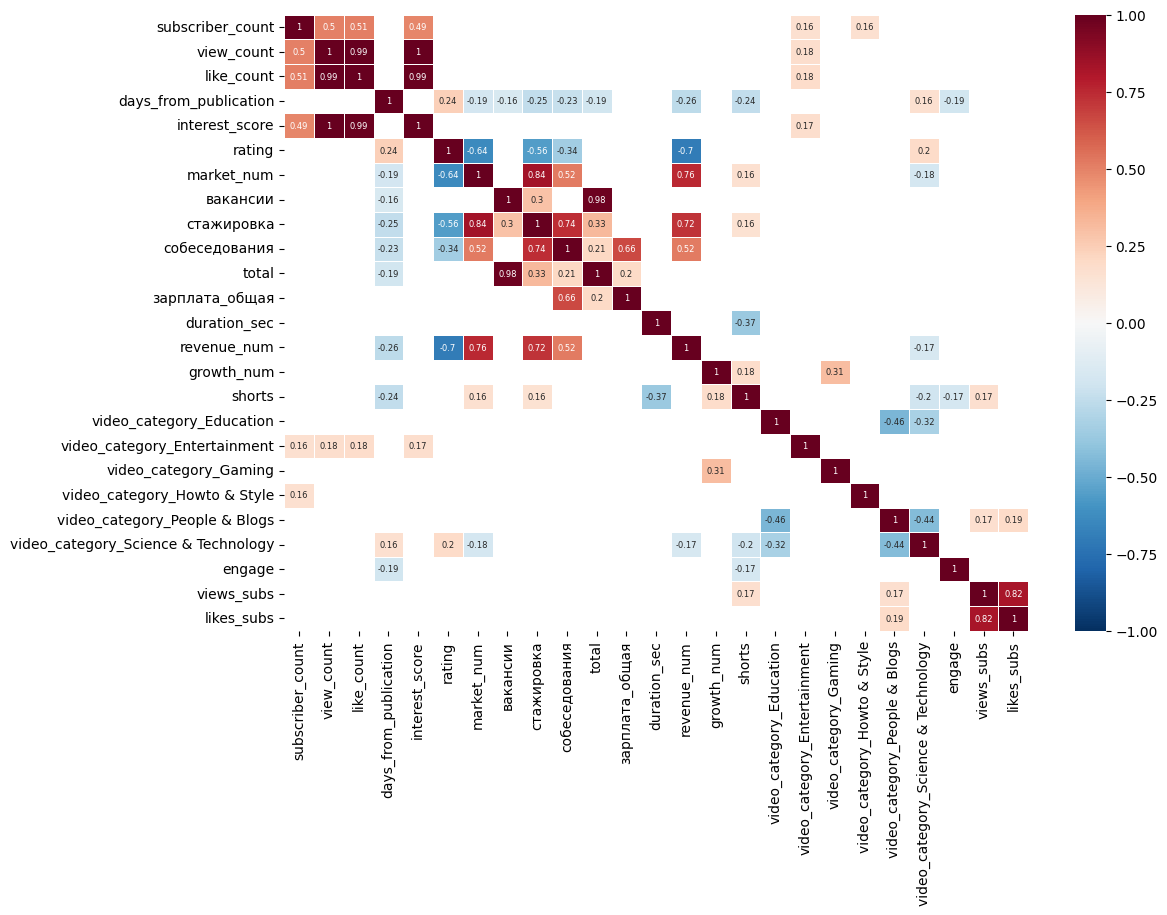

In [75]:
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, 0)

selected_cols = corr_no_diag.columns[(corr_no_diag.abs() > 0.15).any(axis=1)]

corr_filtered = corr.loc[selected_cols, selected_cols]

mask = corr_filtered.abs() <= 0.15

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_filtered,
    vmin=-1, vmax=1, center=0,
    cmap='RdBu_r',
    annot=True,
    linewidths=0.5,
    mask=mask,
    annot_kws={"size": 6}
)
plt.show()

Основная метрика интереса:
- interest_score заметно положительно коррелирует с категорией Entertainment, что говорит о том что все таки кандидатов привлекает видео с тематикой развлечений.

Прокси метрики:
- engage отрицательно коррелирует с количеством дней со дня публикации, что в общем может говорить о том, что чем больше прошло дней со дня публикации видео, тем меньше вероятность высокой вовлеченности - количество просмотров растет, актуальность и интерес аудитории падает, а с ней и количество лайков. В то же время engage отрицательно связан с типом видео (скорее если видео - шортс, то уровень вовлеченности в рамках лайк/просмотр падает - скорее всего люди несильно вовлекаются в короткие видео а скролят их без погружения как фоновую музыку и в том числе не ставят лайки)
- views per subscribers имеет положительную корреляцию с категорией люди и блоги, что в целом говорит о том, что люди больше предпочитают регулярно смотреть на чью то жизнь - а в данном контексте на то, как проходит жизнь в рабочей среде и возможно трудоустройство, первый день в офисе и тд. Также эта метрика положительно связана (с большей вероятностью) с типом видео - если видео короткое, это более интересно смотреть на регулярной основе
- likes_per_subscribers - также как и views per subscribers высоко коррелирует с категорией люди и блоги что говорит о том, что это тип контента нравится юдям больше всего - вот только надо будет посмотреть короткие или длинные видео более всего нравятся пользователям


1) Странно, что дата со дня публикации видео заметно обратно коррелирует с количеством упоминаний в вордстате при поиске карьерных предложений - то есть чем больше дней прошло со дня публикации видео, тем меньше запросов с карьерными целями в яндексе совершают пользователи - более детально посмотрим далее. (в то же время видна заметная положительная линейная связь с местом в рейтинге - чем больше дней со дня публикации, тем дальше от первого места в списке находится компания)

2) Чем больше рынков, на которых работает компания - тем больше карьерных запросов совершается пользователями - видна прямая корреляция - что логично - чем больше рынков - тем больше рабочих мест - тем больше спроса и потока кандидатов (возможно здесь есть влияние знания пользователей об открытых позициях, что побуждает их совершать поиск вакансий у данной компании)


### Посмотрим для начала корреляции отдельно в группах видео и шортсы для полноты картины

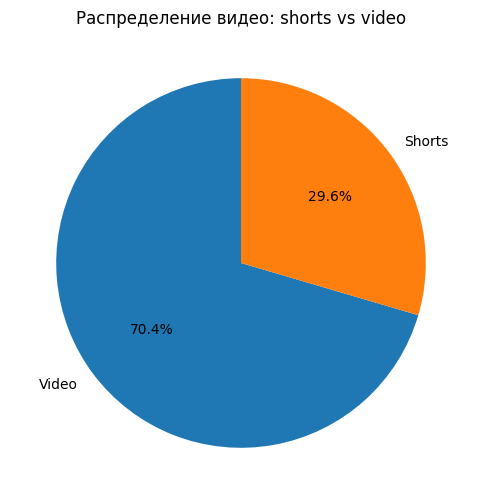

In [76]:
shorts = vw[vw.shorts == 1]
video = vw[vw.shorts == 0]

sizes = [len(video), len(shorts)]
labels = ['Video', 'Shorts']

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Распределение видео: shorts vs video')
plt.show()

Для начала все таки отметим что по нашим фильтрам преобладают обычные видео вопреки представлению о клиповом мышлении нынешнего поколения

#### Видео

<Axes: >

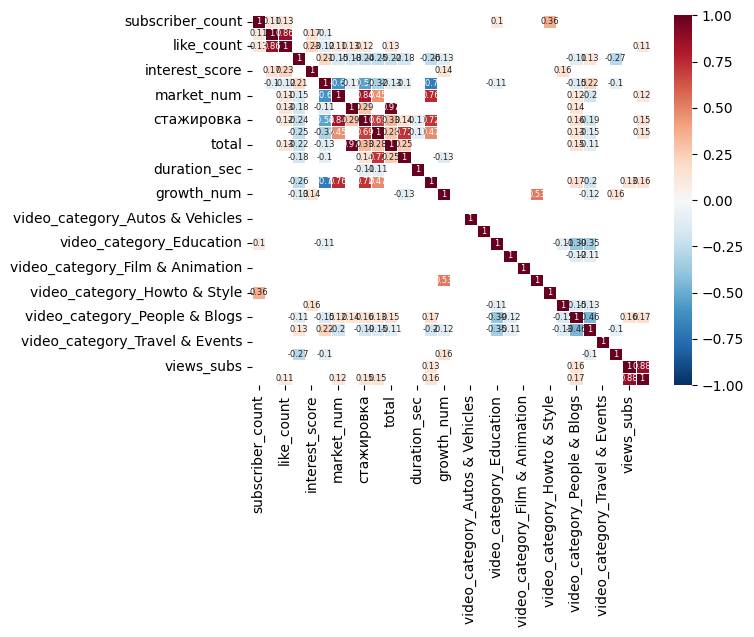

In [81]:
v_corr = video.corr(numeric_only=True)
mask = v_corr.abs() <= 0.1
sns.heatmap(v_corr, vmin=-1, vmax=1, center=0, cmap='RdBu_r', annot=True, linewidth=.5, mask=mask, annot_kws={"size": 6})

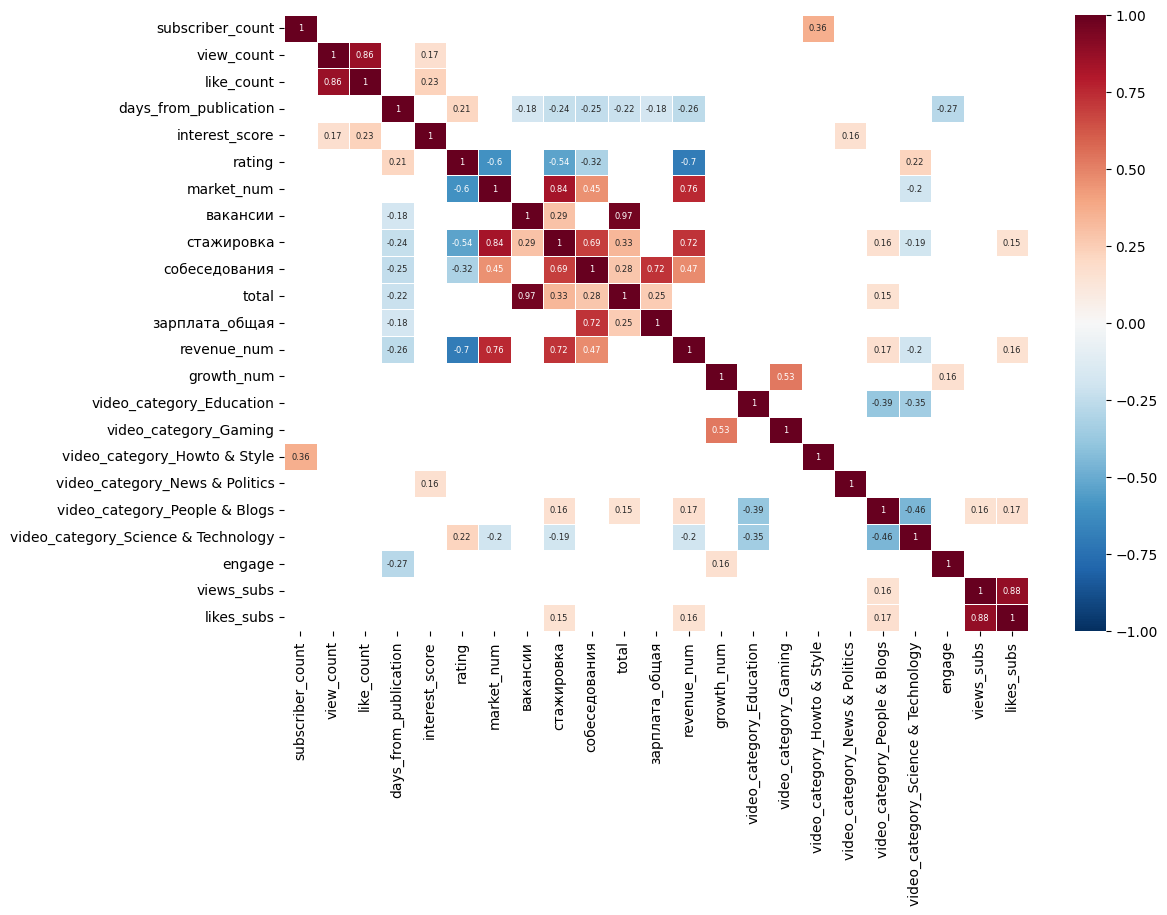

In [82]:
corr_no_diag = v_corr.copy()
np.fill_diagonal(corr_no_diag.values, 0)

selected_cols = corr_no_diag.columns[(corr_no_diag.abs() > 0.15).any(axis=1)]

corr_filtered = v_corr.loc[selected_cols, selected_cols]

mask = corr_filtered.abs() <= 0.15

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_filtered,
    vmin=-1, vmax=1, center=0,
    cmap='RdBu_r',
    annot=True,
    linewidths=0.5,
    mask=mask,
    annot_kws={"size": 6}
)
plt.show()

У видео появляется положительная корреляция likes per subscribers с количеством запросов в вордстате по стажировкам. Также общее количество запросов и количество запросов на стажировку в частности возрастает для категории видео люди и блоги, что упоминали выше. Для этой категории также видна положительная линецная связь с views per subscribers и likes per subscribers. В то же время посчитанная нами сама метрика интересности имеет положительную связь с категорией политики и новостей, что достаточно неожиданно

###Вовлеченность x количество запросов по стажировке

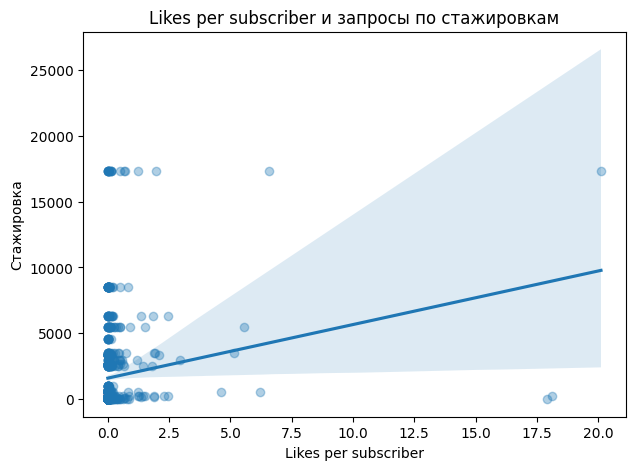

In [99]:
plt.figure(figsize=(7,5))
sns.regplot(data=video, x='likes_subs', y='стажировка', scatter_kws={'alpha':0.35})
plt.title('Likes per subscriber и запросы по стажировкам')
plt.xlabel('Likes per subscriber')
plt.ylabel('Стажировка')
plt.show()

Общий положительный тренд количества запросов по стажировке виден с ростом количества лайков/количество подписчиков, что говорит о вероятной взаимосвязи и полезности продвижения компании через контент для привлечения стажеров на открытые позиции

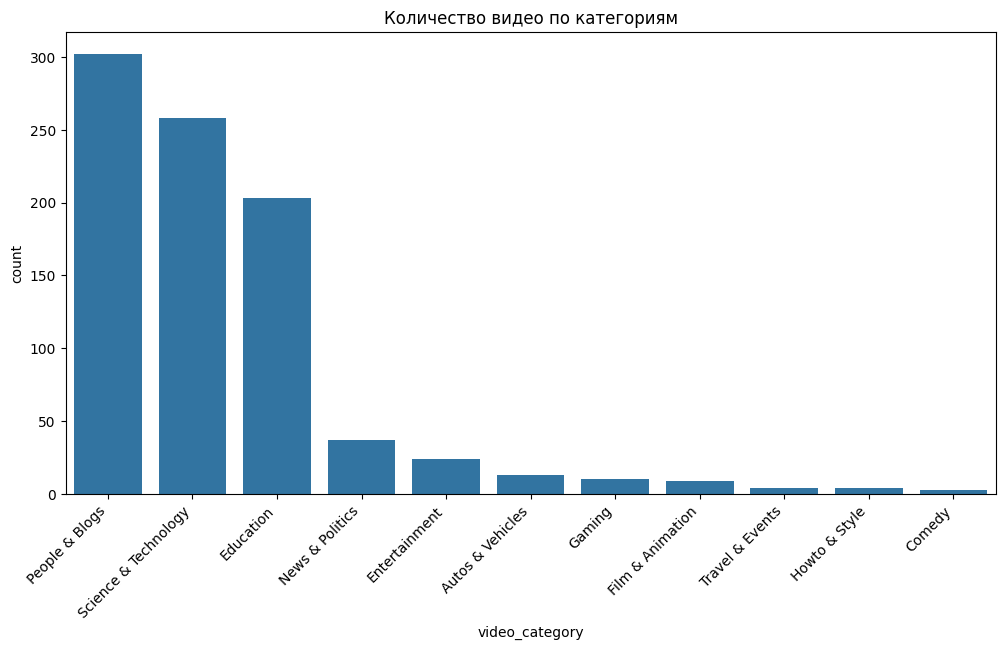

In [107]:
plt.figure(figsize=(12,6))
sns.countplot(data=video, x='video_category', order=video['video_category'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Количество видео по категориям')
plt.show()

Все таки делать вывод о том, что блоги интереснее - слишком поспешно, однако учитывая то, как собирался сам датасет топ три самых интересных категории среди кользователей (не по нашей версии) - блоги, наука и технологии и образование

#### Шортс

<Axes: >

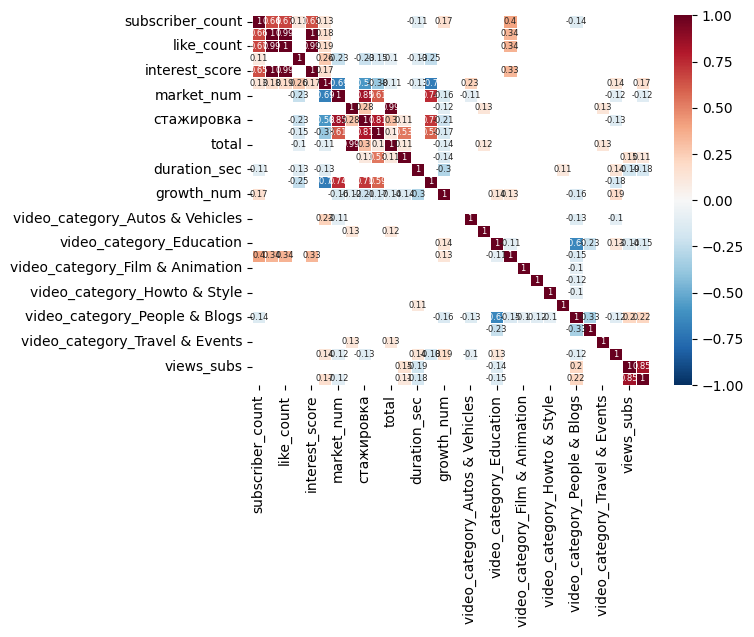

In [85]:
sh_corr = shorts.corr(numeric_only=True)
mask = sh_corr.abs() <= 0.1
sns.heatmap(sh_corr, vmin=-1, vmax=1, center=0, cmap='RdBu_r', annot=True, linewidth=.5, mask=mask, annot_kws={"size": 6})

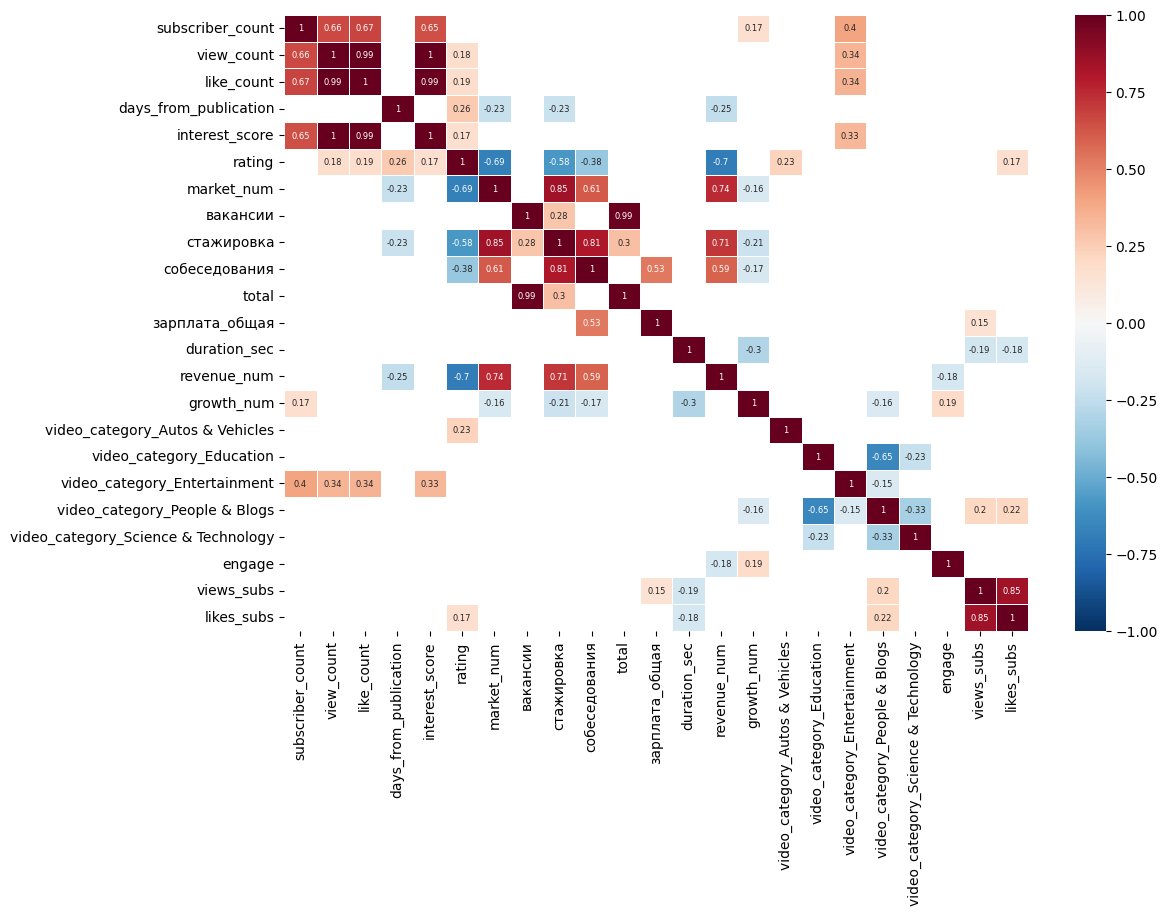

In [86]:
corr_no_diag = sh_corr.copy()
np.fill_diagonal(corr_no_diag.values, 0)

selected_cols = corr_no_diag.columns[(corr_no_diag.abs() > 0.15).any(axis=1)]

corr_filtered = sh_corr.loc[selected_cols, selected_cols]

mask = corr_filtered.abs() <= 0.15

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_filtered,
    vmin=-1, vmax=1, center=0,
    cmap='RdBu_r',
    annot=True,
    linewidths=0.5,
    mask=mask,
    annot_kws={"size": 6}
)
plt.show()

Для шортс также сохраняется положительная связь с категорией Блоги и люди.

Метрики:
- likes_per_subscribers отрицательно коррелирует с продолжительностью также как и views per subsribers. Первый факт может говорить о том, что чем дольше длится видео, тем меньше лайков оно получает от пользователей и скорее всего пролистнется. Второй факт в целом про то же, но тут слишком грубо делать какие-то выводы на такой выборке, ожнако если все же делать их - то чем дольше ютуб шортс - тем меньше вероятность, что его посмотрят, либо же это обычные видео с низкой продолжительностью, которые с низкой вероятностью кто то откроет, а в шортс они не попадают
- interest_score имеет заметную положительную корреляцию с категорией развлечений - причем эта корреляция выросла по сравнению с исходными посчитанными связями

Посмотрим на количество шортс по категориям видео

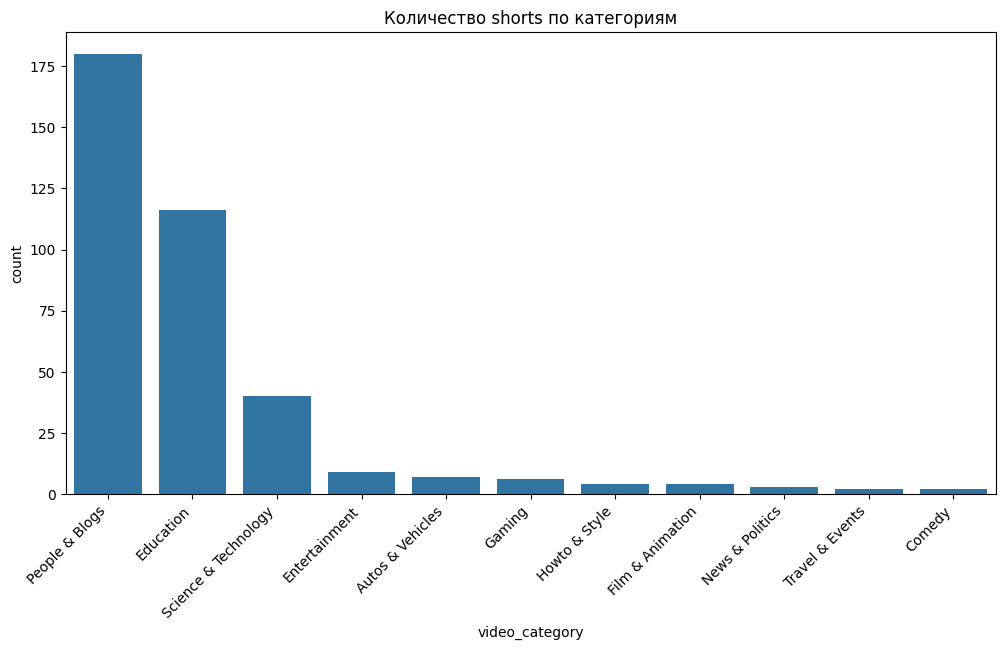

In [133]:
plt.figure(figsize=(12,6))
sns.countplot(data=shorts, x='video_category',
              order=shorts['video_category'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Количество shorts по категориям')
plt.show()

По сравнению с видео образование немного вырывается вперед по количеству по сравнению с наукой и технологиями, однако блоги и люди остаются в топе

Посмотрим на все метрики в разрезе конкретных компаний (чтобы избежать искажения результатов из-за того, что метрики вордстата повторяются для каждого видео одной и той же компании)

In [134]:
company_df = (
    vw.groupby('company', as_index=False)
      .agg(
          video_cnt=('video_url', 'count'),
          shorts_share=('shorts', 'mean'),
          avg_views_subs=('views_subs', 'mean'),
          avg_likes_subs=('likes_subs', 'mean'),
          avg_engage=('engage', 'mean'),
          avg_interest_score=('interest_score', 'mean'),
          avg_duration=('duration_sec', 'mean'),
          total=('total', 'max'),
          вакансии=('вакансии', 'max'),
          стажировка=('стажировка', 'max'),
          собеседования=('собеседования', 'max'),
          зарплата_общая=('зарплата_общая', 'max'),
          rating=('rating', 'max'),
          revenue_num=('revenue_num', 'max'),
          growth_num=('growth_num', 'max'),
          market_num=('market_num', 'max')
      )
)

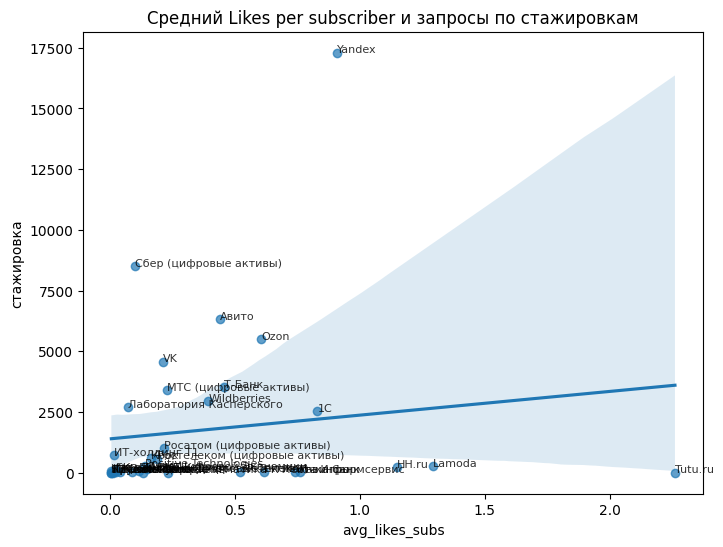

In [139]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=company_df,
    x='avg_likes_subs',
    y='стажировка',
    scatter_kws={'alpha': 0.7}
)

for _, row in company_df.iterrows():
    plt.text(row['avg_likes_subs'], row['стажировка'], str(row['company']), fontsize=8, alpha=0.8)

plt.title('Средний Likes per subscriber и запросы по стажировкам')
plt.xlabel('avg_likes_subs')
plt.ylabel('стажировка')
plt.show()

Очень много компаний лежит внизу по причине недостатка по ним данным из-за ограниченности апи ключа (не удалось дособрать данные по ним)

In [141]:
company_corr = company_df[['avg_likes_subs', 'avg_views_subs', 'shorts_share', 'avg_interest_score', 'стажировка', 'total', 'rating']].corr()


<Axes: >

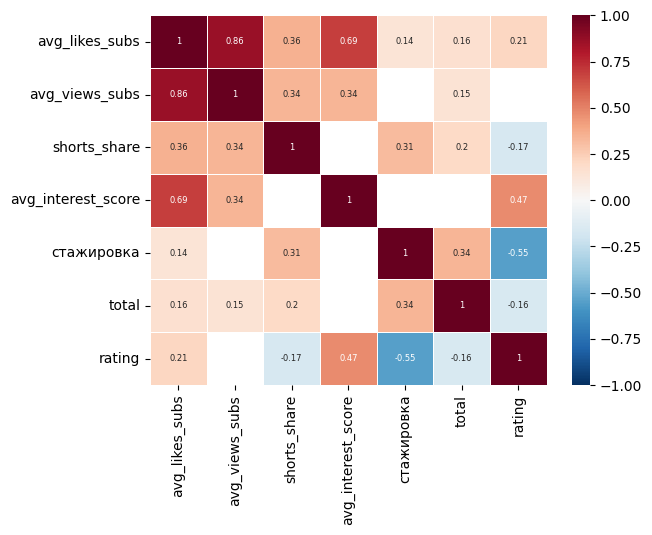

In [143]:
mask = company_corr.abs() <= 0.1
sns.heatmap(company_corr, vmin=-1, vmax=1, center=0, cmap='RdBu_r', annot=True, linewidth=.5, mask=mask, annot_kws={"size": 6})

In [150]:
vw30 = vw[vw['rating'] <= 30].copy()
vw30.shape

(1131, 50)

In [151]:
company_df30 = (
    vw30.groupby('company', as_index=False)
      .agg(
          video_cnt=('video_url', 'count'),
          shorts_share=('shorts', 'mean'),
          avg_views_subs=('views_subs', 'mean'),
          avg_likes_subs=('likes_subs', 'mean'),
          avg_engage=('engage', 'mean'),
          avg_interest_score=('interest_score', 'mean'),
          avg_duration=('duration_sec', 'mean'),
          total=('total', 'max'),
          вакансии=('вакансии', 'max'),
          стажировка=('стажировка', 'max'),
          собеседования=('собеседования', 'max'),
          зарплата_общая=('зарплата_общая', 'max'),
          rating=('rating', 'max'),
          revenue_num=('revenue_num', 'max'),
          growth_num=('growth_num', 'max'),
          market_num=('market_num', 'max')
      )
)

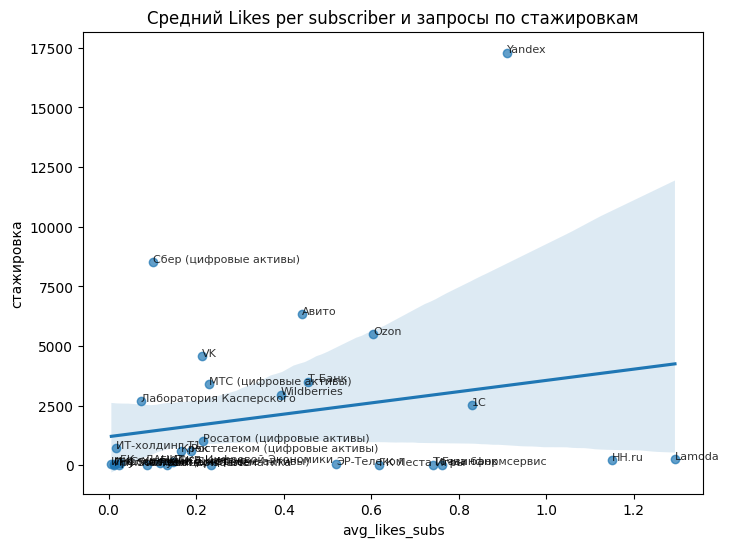

In [152]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=company_df30,
    x='avg_likes_subs',
    y='стажировка',
    scatter_kws={'alpha': 0.7}
)

for _, row in company_df30.iterrows():
    plt.text(row['avg_likes_subs'], row['стажировка'], str(row['company']), fontsize=8, alpha=0.8)

plt.title('Средний Likes per subscriber и запросы по стажировкам')
plt.xlabel('avg_likes_subs')
plt.ylabel('стажировка')
plt.show()

In [154]:
company_corr30 = company_df30[['avg_likes_subs', 'avg_views_subs', 'shorts_share', 'avg_interest_score', 'стажировка', 'total', 'rating']].corr()

<Axes: >

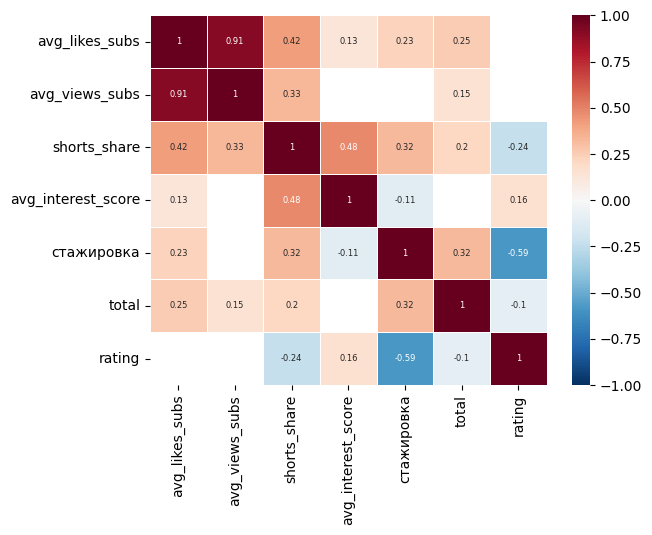

In [155]:
mask = company_corr30.abs() <= 0.1
sns.heatmap(company_corr30, vmin=-1, vmax=1, center=0, cmap='RdBu_r', annot=True, linewidth=.5, mask=mask, annot_kws={"size": 6})


- Чем выше компания в рейтинге, тем больше запросов на стажировку поступет от кандидатов в поисковике
- Чем больше доля коротких видео у компании, тем выше уровень интересности среди кандидатов в медиа пространстве
- Что интересно, с ростом доли коротких видео растет количество запросов в вордстате по трудоустройству (стажировка)
- также доля коротких видео положительно влияет на прокси метрики вовлеченности

Итоговые рекомендации на основе исследования:

- Делать больше коротких видео - это (пока что нет статистически значимых оснований) с большой вероятностью повлияет не только на вовлеченность ЦА в медиа, но и на заинтересованность кандидатов в трудоустройстве
- Ориентироваться в шортсах на развлекательный контент и не затягивать в продолжительности
- Обычные видео стоит делать в категории People and Blogs - снимать жизнь в компании, первый рабочий день, онбординг
